In [105]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="Simple-v1",
    total_episodes=100_000,
    learning_rate=1.0,
    gamma=0.95,
    epsilon=1.0,
    map_size=(3,3),
    seed=123,
    is_slippery=False,
    n_runs=1,
    action_size=None,
    state_size=None,
    n_quantiles=64,
    use_lr_decay=True,
    save_skip=1_000,
    huber_k=0
)
rng = np.random.default_rng(params.seed)

In [106]:
env = gym.make(params.model_name)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

Run 0/1 - Episodes: 100%|██████████| 100000/100000 [00:04<00:00, 20591.99it/s]


In [5084]:
gamma = 1.0
n_quantiles = 52
state = 4
new_state = 1
action = 0
theta = np.zeros((9, 1, n_quantiles))
tau = ((2 * np.arange(n_quantiles) + 1) / (2.0 * n_quantiles))

In [ ]:
for _ in range(1000):
    env.reset()
    _, reward, done, term, info = env.step(0)
    
    pred_quantiles = theta[state, action]
    target_quantiles = reward + gamma * theta[new_state, theta[new_state].mean(1).argmax()]
    u = pred_quantiles[:, None] - target_quantiles[None, :]

    grad_loss = -np.abs(tau[:, None] - (u < 0)) * du_huber(u)
    theta[state, action] += 0.001 * grad_loss.mean(1)
print(theta[state, action].round(1))

[ 1.9  1.5  1.3  1.2  1.1  1.   0.9  0.8  0.8  0.7  0.6  0.6  0.5  0.5
  0.4  0.4  0.4  0.3  0.3  0.2  0.2  0.2  0.1  0.1  0.1  0.  -0.  -0.
 -0.1 -0.1 -0.2 -0.2 -0.2 -0.3 -0.3 -0.3 -0.4 -0.4 -0.5 -0.5 -0.6 -0.6
 -0.7 -0.7 -0.8 -0.9 -0.9 -1.  -1.2 -1.3 -1.5 -2. ]


In [94]:
def _dist_bimodal(): return np.random.normal(-2 if (np.random.random() < 0.5) else 2, 1.0)

_dist_bimodal()

-3.837202143321486

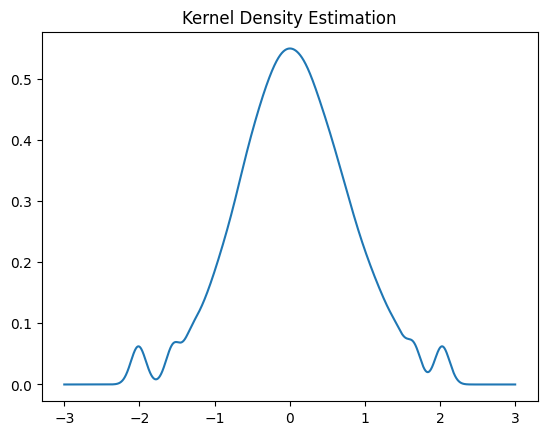

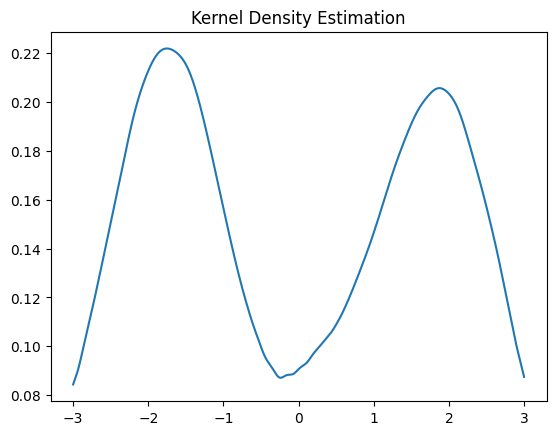

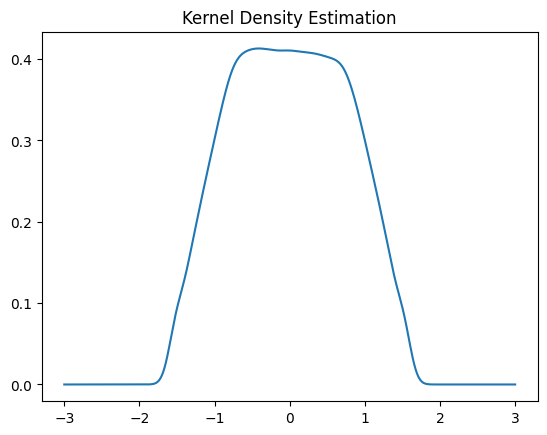

In [ ]:
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity

state = 4
bandwidth = 0.1

for action in range(params.action_size):
    action_quantiles = tables[-1, state, action]
    samples = action_quantiles[:, None]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    # log_pdf = kde.score_samples(samples)
    # pdf = np.exp(log_pdf)
    # x = samples[:,0]
    
    x_grid = np.linspace(-3, 3, 10_000)[:, None]
    log_pdf = kde.score_samples(x_grid)
    pdf = np.exp(log_pdf)

    plt.plot(x_grid[:,0], pdf)
    plt.title("Kernel Density Estimation")
    plt.show()